In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# データファイルの読み込み
data = np.loadtxt("orca.relaxscanact.dat")

# データフレームに変換
df = pd.DataFrame(data, columns=["Distance", "Energy"])

# ステップ番号を追加（1から始まる）
df["Step"] = np.arange(1, len(df) + 1)

# エネルギーをHartreeからkcal/molに変換
hartree_to_kcalmol = 627.509474
df["Energy_kcal"] = (df["Energy"] - df["Energy"].min()) * hartree_to_kcalmol

print("データの最初の10行:")
print(df.head(10))
print(f"\n総ステップ数: {len(df)}")
print(f"エネルギー最小値: {df['Energy'].min():.6f} Hartree")
print(f"エネルギー最大値: {df['Energy'].max():.6f} Hartree")
print(
    f"エネルギー範囲: {(df['Energy'].max() - df['Energy'].min()) * hartree_to_kcalmol:.2f} kcal/mol"
)

データの最初の10行:
   Distance       Energy  Step  Energy_kcal
0     3.245 -1967.143572     1    30.937623
1     3.225 -1967.143577     2    30.934780
2     3.205 -1967.143561     3    30.944638
3     3.185 -1967.143542     4    30.956492
4     3.165 -1967.143509     5    30.977018
5     3.145 -1967.143462     6    31.006956
6     3.125 -1967.143425     7    31.030143
7     3.105 -1967.143355     8    31.073635
8     3.085 -1967.143302     9    31.106912
9     3.065 -1967.143216    10    31.161267

総ステップ数: 126
エネルギー最小値: -1967.192874 Hartree
エネルギー最大値: -1967.039628 Hartree
エネルギー範囲: 96.16 kcal/mol


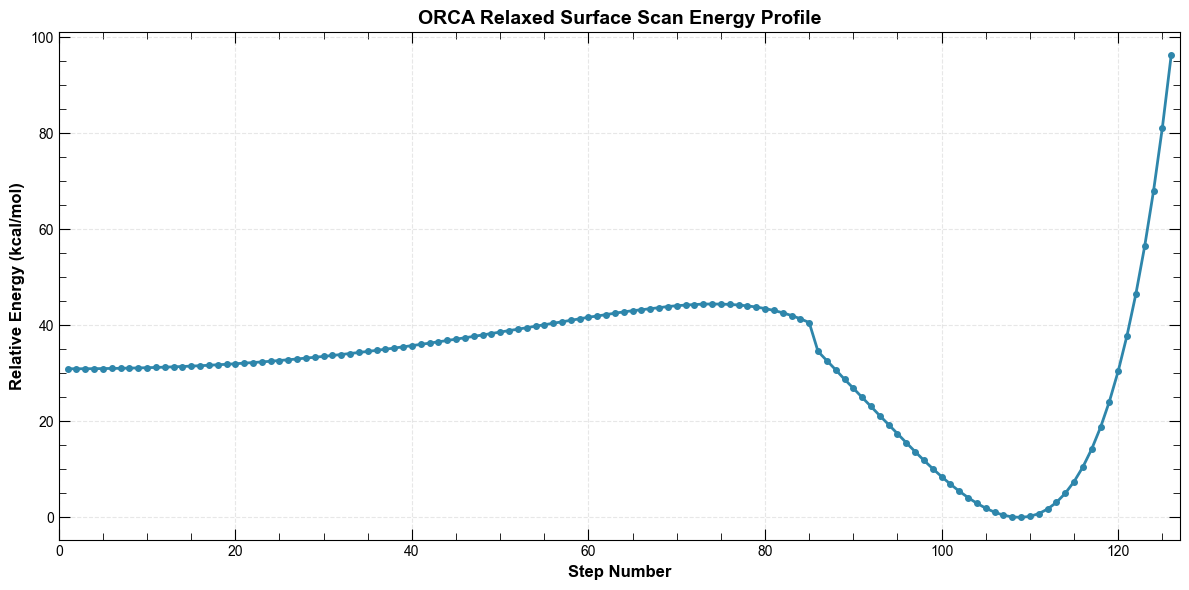


プロットを 'scan_energy_vs_step.png' として保存しました。


In [ ]:
# プロット作成
fig, ax = plt.subplots(figsize=(12, 6))

# ステップ数 vs エネルギー
ax.plot(df["Step"], df["Energy_kcal"], "o-", linewidth=2, markersize=4, color="#2E86AB")
ax.set_xlabel("Step Number", fontsize=12, fontweight="bold")
ax.set_ylabel("Relative Energy (kcal/mol)", fontsize=12, fontweight="bold")
ax.set_title("ORCA Relaxed Surface Scan Energy Profile", fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.3, linestyle="--")
ax.set_xlim(0, len(df) + 1)

plt.tight_layout()
plt.savefig("scan_energy_vs_step.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nプロットを 'scan_energy_vs_step.png' として保存しました。")

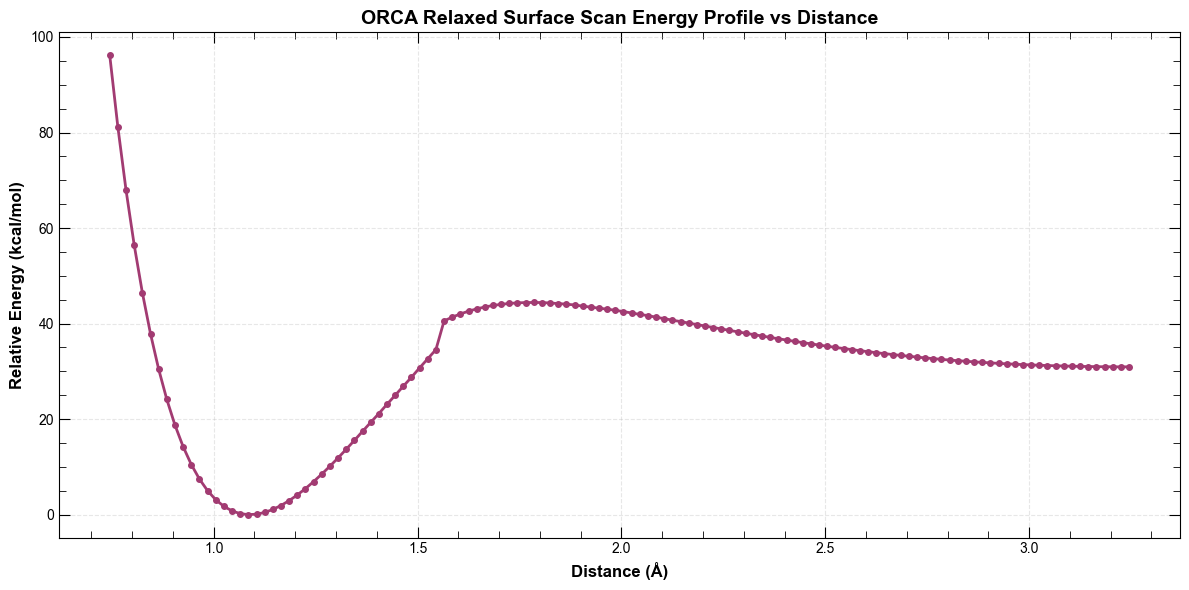


プロットを 'scan_energy_vs_distance.png' として保存しました。


In [ ]:
# 距離 vs エネルギーのプロットも作成
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    df["Distance"], df["Energy_kcal"], "o-", linewidth=2, markersize=4, color="#A23B72"
)
ax.set_xlabel("Distance (Å)", fontsize=12, fontweight="bold")
ax.set_ylabel("Relative Energy (kcal/mol)", fontsize=12, fontweight="bold")
ax.set_title(
    "ORCA Relaxed Surface Scan Energy Profile vs Distance",
    fontsize=14,
    fontweight="bold",
)
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.savefig("scan_energy_vs_distance.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nプロットを 'scan_energy_vs_distance.png' として保存しました。")

In [ ]:
# エネルギー最大値（遷移状態の推定位置）を見つける
max_energy_idx = df["Energy_kcal"].idxmax()
print(f"\n推定遷移状態:")
print(f"  ステップ番号: {df.loc[max_energy_idx, 'Step']:.0f}")
print(f"  距離: {df.loc[max_energy_idx, 'Distance']:.5f} Å")
print(f"  相対エネルギー: {df.loc[max_energy_idx, 'Energy_kcal']:.2f} kcal/mol")


推定遷移状態:
  ステップ番号: 126
  距離: 0.74500 Å
  相対エネルギー: 96.16 kcal/mol


In [ ]:
# ステップ数60~100の間の極大値を取り出す
from scipy.signal import argrelextrema

# ステップ60~100の範囲のデータを抽出
df_range = df[(df["Step"] >= 60) & (df["Step"] <= 100)].copy()

# 極大値を見つける（order=1は隣接する点との比較）
local_max_indices = argrelextrema(df_range["Energy_kcal"].values, np.greater, order=1)[
    0
]

if len(local_max_indices) > 0:
    print(f"\nステップ60~100の間の極大値:")
    print("-" * 60)
    for idx in local_max_indices:
        actual_step = df_range.iloc[idx]["Step"]
        actual_distance = df_range.iloc[idx]["Distance"]
        actual_energy = df_range.iloc[idx]["Energy_kcal"]
        print(f"  ステップ番号: {actual_step:.0f}")
        print(f"  距離: {actual_distance:.5f} Å")
        print(f"  相対エネルギー: {actual_energy:.2f} kcal/mol")
        print()

    # 最大の極大値を見つける
    max_local_idx = local_max_indices[
        np.argmax(df_range.iloc[local_max_indices]["Energy_kcal"].values)
    ]
    max_step = df_range.iloc[max_local_idx]["Step"]
    max_distance = df_range.iloc[max_local_idx]["Distance"]
    max_energy = df_range.iloc[max_local_idx]["Energy_kcal"]

    print(f"最大の極大値（推定遷移状態）:")
    print(f"  ステップ番号: {max_step:.0f}")
    print(f"  距離: {max_distance:.5f} Å")
    print(f"  相対エネルギー: {max_energy:.2f} kcal/mol")
else:
    print("\nステップ60~100の間に極大値が見つかりませんでした。")


ステップ60~100の間の極大値:
------------------------------------------------------------
  ステップ番号: 74
  距離: 1.78500 Å
  相対エネルギー: 44.41 kcal/mol

最大の極大値（推定遷移状態）:
  ステップ番号: 74
  距離: 1.78500 Å
  相対エネルギー: 44.41 kcal/mol
